# Mini-Projeto MNIST - Classificação de Dígitos Manuscritos

**Análise Preditiva com Python - Módulo 2**

Pipeline ponta a ponta de Machine Learning para classificacao multiclasse de dígitos manuscritos (0-9) utilizando o dataset MNIST.

## Fase 1: Carregamento e Análise Exploratória de Imagens (EDA)

In [1]:
# Bibliotecas para manipulação de dados e visualização
import numpy as np
import matplotlib.pyplot as plt

# Função do scikit-learn para baixar o dataset MNIST diretamente do OpenML
from sklearn.datasets import fetch_openml

print("Baixando o dataset MNIST...")

# fetch_openml carrega o dataset mnist_784 (70.000 imagens 28x28 = 784 pixels)
# as_frame=False retorna arrays numpy ao em vez de DataFrame pandas
# data_home="./data" salva o dataset localmente no projeto
mnist = fetch_openml("mnist_784", version=1, as_frame=False, parser="auto", data_home="./data")
print("Finalizou o processo de baixar o dataset MNIST!")

# Separar features (X) e labels (y)
# X contêm os 784 pixels de cada imagem (vetorizado)
# y contêm o rótulo do dígito (0-9), convertido de string para inteiro
X, y = mnist.data, mnist.target.astype(int)

# Exibir dimensionalidade para comprovar a estrutura dos dados
print(f"Dimensionalidade de X: {X.shape}")
print(f"Dimensionalidade de y: {y.shape}")
print(f"Total de amostras: {X.shape[0]}")
print(f"Total de features (pixels): {X.shape[1]}")
print(f"Formato de cada imagem: 28x28 = {28*28} pixels")
print(f"Valores únicos de y: {np.unique(y)}")

Baixando o dataset MNIST...
Finalizou o processo de baixar o dataset MNIST!
Dimensionalidade de X: (70000, 784)
Dimensionalidade de y: (70000,)
Total de amostras: 70000
Total de features (pixels): 784
Formato de cada imagem: 28x28 = 784 pixels
Valores únicos de y: [0 1 2 3 4 5 6 7 8 9]


In [2]:
# Estatísticas dos pixels - comprovação numérica da escala 0-255
print(f"Valor mínimo de pixel: {X.min():.0f}")
print(f"Valor máximo de pixel: {X.max():.0f}")
print(f"Valor média de pixel: {X.mean():.2f}")
print(f"Desvio padrão dos pixels: {X.std():.2f}")

# Verificar a integridade dos dados (valores nulos ou negativos)
print(f"Existem valores nulos? {np.isnan(X).any()}")
print(f"Existem valores negativos? {(X < 0).any()}")

# Verificar se o dataset é balanceado entre as classes
unique, counts = np.unique(y, return_counts=True)
print(f"\nBalanceamento das classes:")
print(f"  Minimo de amostras por classe: {counts.min()} (dígito {unique[counts.argmin()]})")
print(f"  Maximo de amostras por classe: {counts.max()} (dígito {unique[counts.argmax()]})")
print(f"  Diferença máxima entre classes: {counts.max() - counts.min()} amostras")

Valor mínimo de pixel: 0
Valor máximo de pixel: 255
Valor média de pixel: 33.39
Desvio padrão dos pixels: 78.65
Existem valores nulos? False
Existem valores negativos? False

Balanceamento das classes:
  Minimo de amostras por classe: 6313 (dígito 5)
  Maximo de amostras por classe: 7877 (dígito 1)
  Diferença máxima entre classes: 1564 amostras


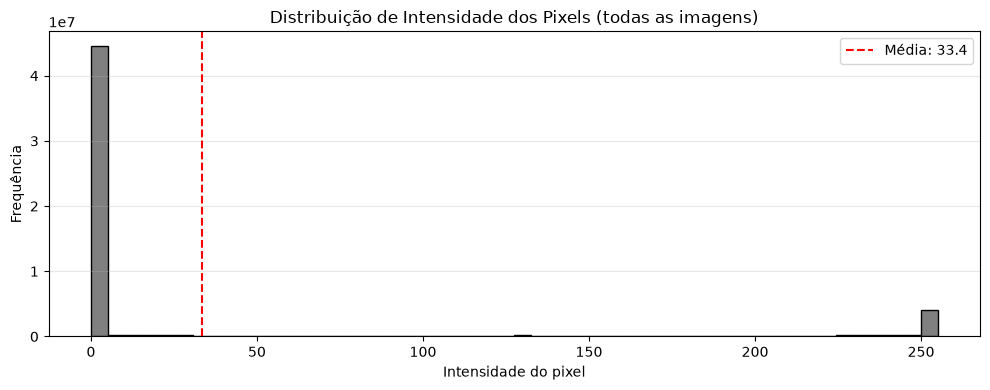

A maioria dos pixels é próxima de 0 (fundo preto das imagens).
Isso indica que as imagens são esparsas - o dígito ocupa apenas uma parte da área 28x28.


In [3]:
# Histograma de intensidade dos pixels
# Achatamos todas as imagens em um único vetor para analisar a distribuição global
plt.figure(figsize=(10, 4))
plt.hist(X.flatten(), bins=50, color="gray", edgecolor="black")
plt.xlabel("Intensidade do pixel")
plt.ylabel("Frequência")
plt.title("Distribuição de Intensidade dos Pixels (todas as imagens)")

# Linha vertical indicando a média global dos pixels
plt.axvline(X.mean(), color="red", linestyle="--", label=f"Média: {X.mean():.1f}")
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

# Interpretação do histograma
print("A maioria dos pixels é próxima de 0 (fundo preto das imagens).")
print("Isso indica que as imagens são esparsas - o dígito ocupa apenas uma parte da área 28x28.")

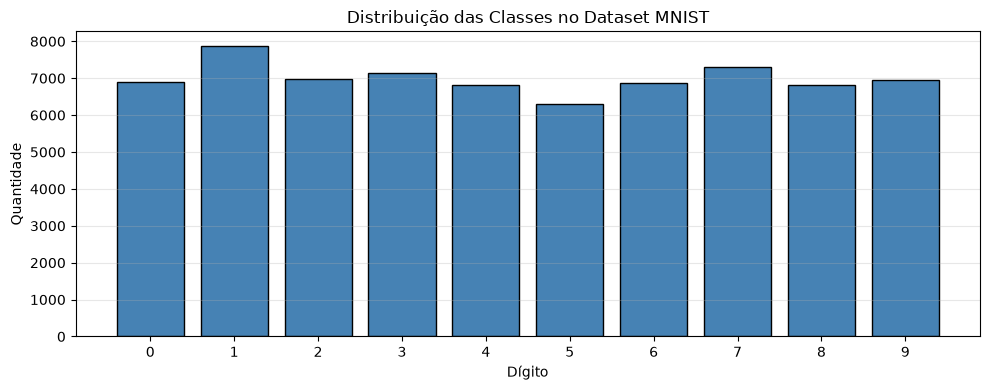

  Dígito 0: 6903 amostras (9.9%)
  Dígito 1: 7877 amostras (11.3%)
  Dígito 2: 6990 amostras (10.0%)
  Dígito 3: 7141 amostras (10.2%)
  Dígito 4: 6824 amostras (9.7%)
  Dígito 5: 6313 amostras (9.0%)
  Dígito 6: 6876 amostras (9.8%)
  Dígito 7: 7293 amostras (10.4%)
  Dígito 8: 6825 amostras (9.8%)
  Dígito 9: 6958 amostras (9.9%)


In [4]:
# Gráfico de barras mostrando a quantidade de amostras por classe
# Valores únicos e suas contagens já foram calculados na célula anterior
plt.figure(figsize=(10, 4))
plt.bar(unique, counts, color="steelblue", edgecolor="black")
plt.xlabel("Dígito")
plt.ylabel("Quantidade")
plt.title("Distribuição das Classes no Dataset MNIST")
plt.xticks(unique)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

# Exibir a quantidade exata de amostras por classe
for dígito, qtd in zip(unique, counts):
    pct = qtd / len(y) * 100
    print(f"  Dígito {dígito}: {qtd} amostras ({pct:.1f}%)")

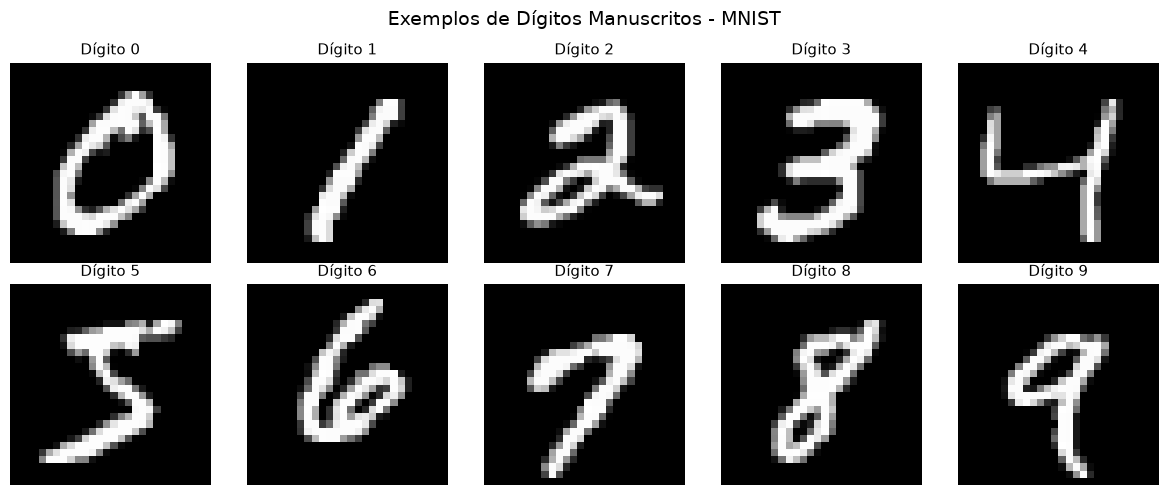

In [5]:
# Grade visual 2x5 com um exemplo de cada dígito (0-9)
# Usamos subplots para criar uma grade de 2 linhas x 5 colunas
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
fig.suptitle("Exemplos de Dígitos Manuscritos - MNIST", fontsize=14)

# Para cada dígito, encontramos a primeira ocorrência no dataset
for i in range(10):
    ax = axes[i // 5, i % 5]  # Posição no grid: linha = i//5, coluna = i%5
    idx = np.where(y == i)[0][0]  # Primeiro índice onde y == i
    ax.imshow(X[idx].reshape(28, 28), cmap="gray")  # Reshape de 784 para 28x28
    ax.set_title(f"Dígito {i}", fontsize=11)
    ax.axis("off")

plt.tight_layout()
plt.show()

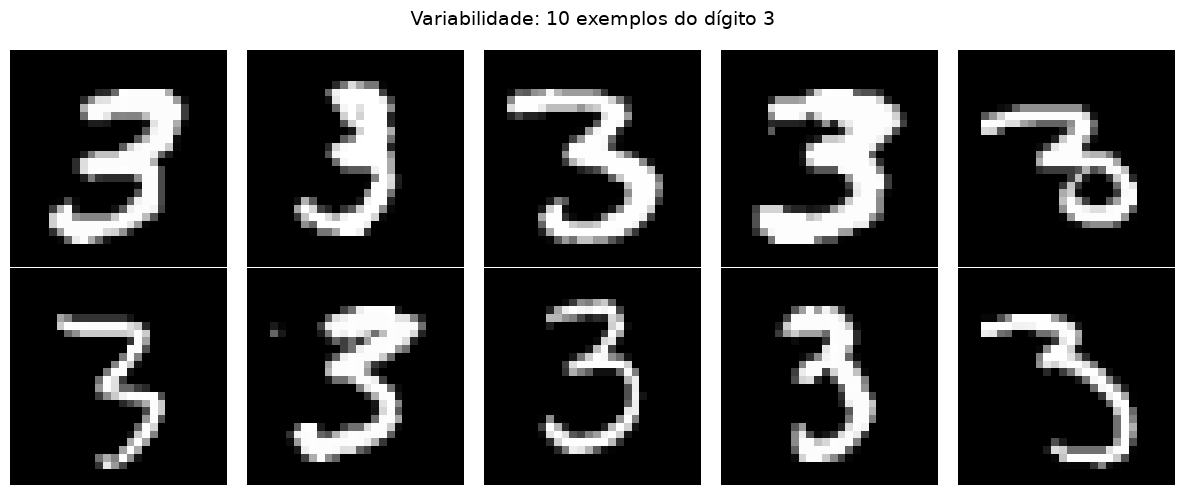

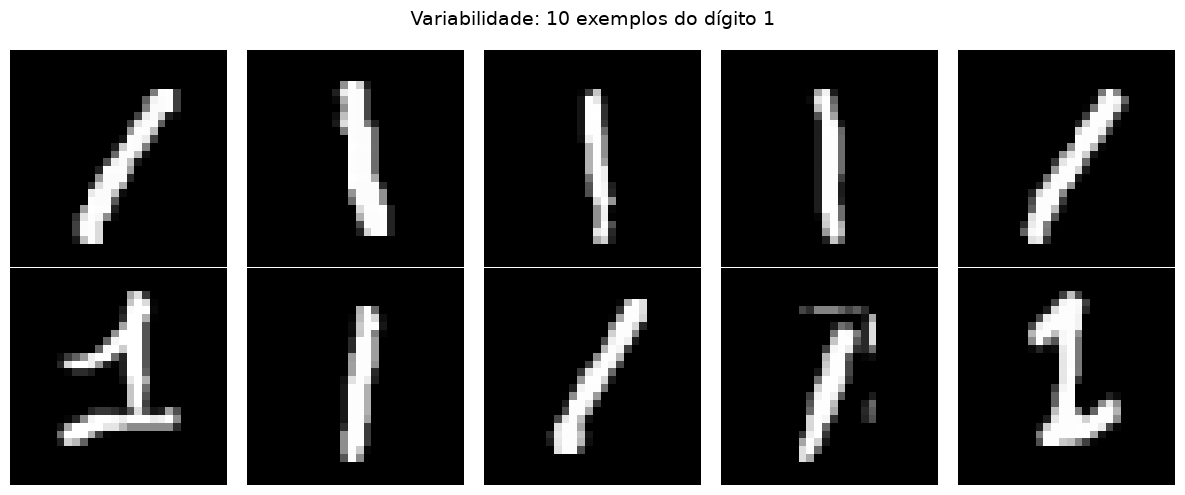

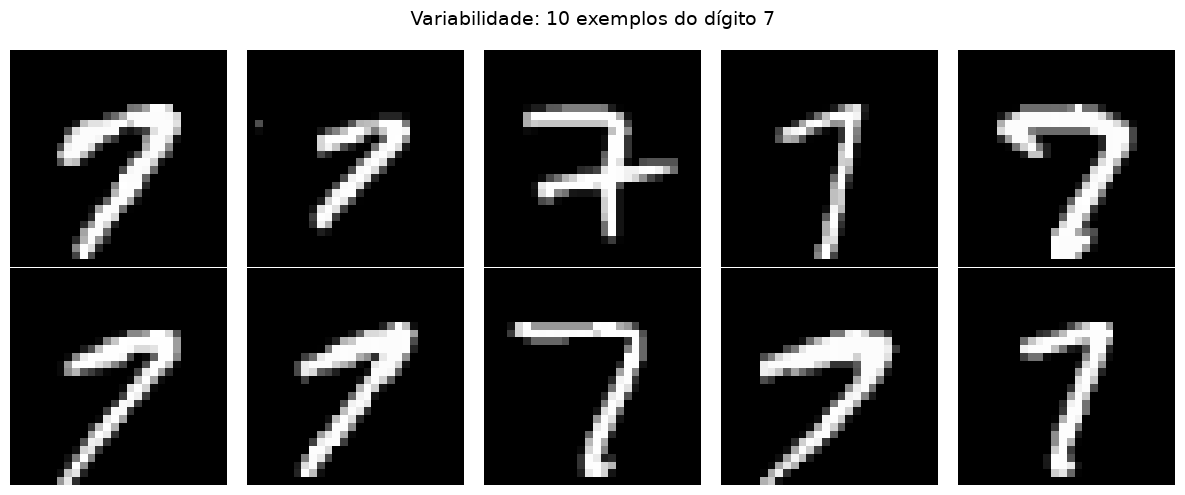

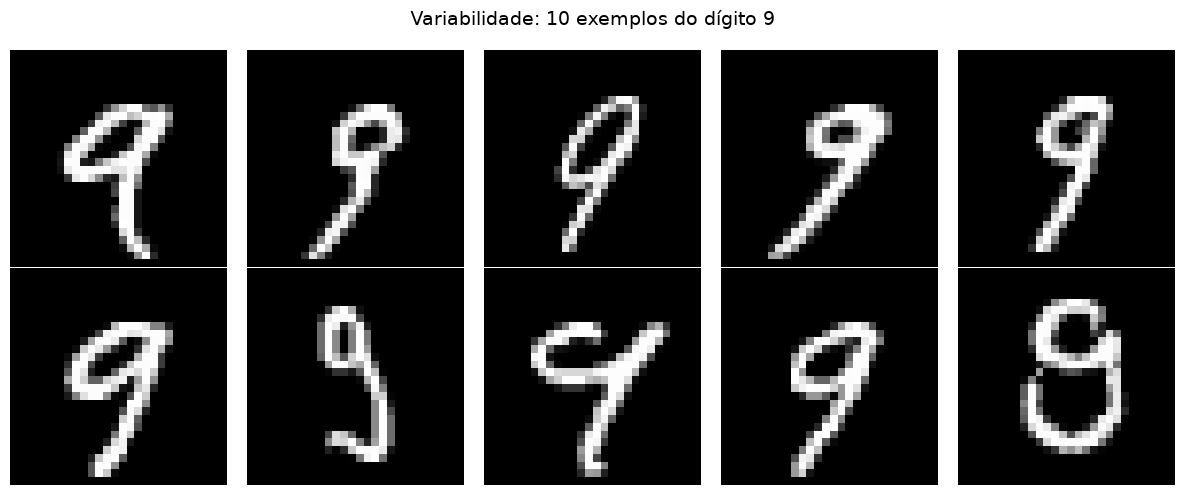

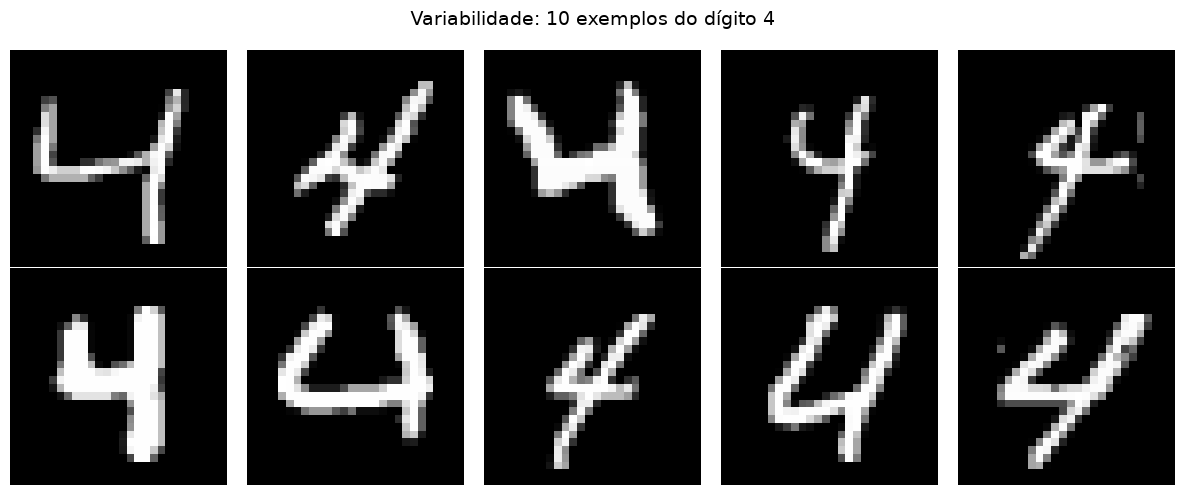

In [6]:
# Variabilidade intra-classe: mostrar que o mesmo dígito varia entre escritores
# Selecionamos 5 dígitos diferentes e mostramos 10 exemplos de cada
dígitos_exemplo = [3, 1, 7, 9, 4]

for dígito in dígitos_exemplo:
    # Coletar os primeiros 10 índices deste dígito
    índices = np.where(y == dígito)[0][:10]
    
    fig, axes = plt.subplots(2, 5, figsize=(12, 5))
    fig.suptitle(f"Variabilidade: 10 exemplos do dígito {dígito}", fontsize=14)
    
    for i in range(10):
        ax = axes[i // 5, i % 5]
        ax.imshow(X[índices[i]].reshape(28, 28), cmap="gray")
        ax.axis("off")
    
    plt.tight_layout()
    plt.show()

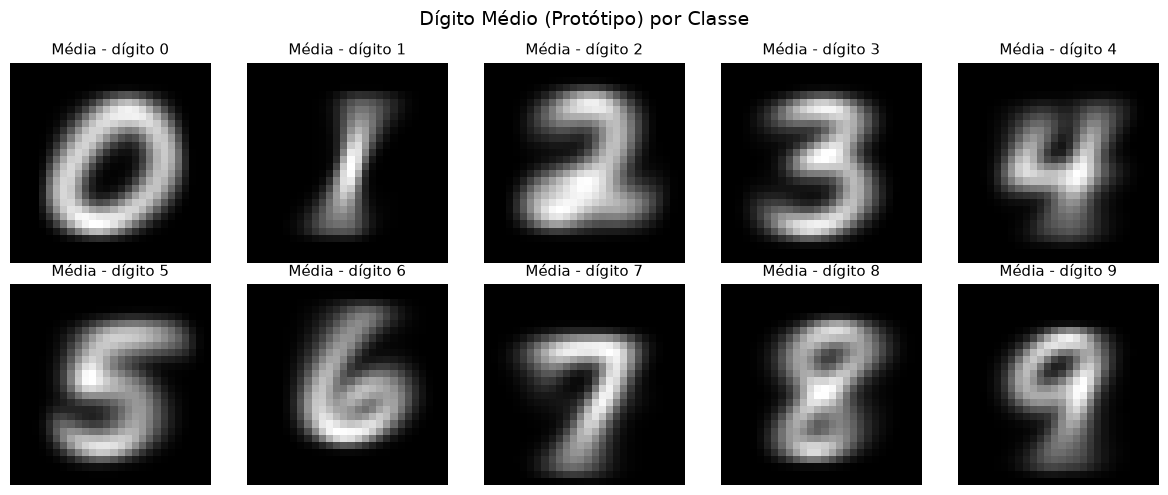

Nota: os protótipos médias dos dígitos 4 e 9 são visualmente similares,
o que justifica por que modelos frequentemente confundem essas classes.


In [7]:
# Dígito média (protótipo) por classe
# Calculamos a média pixel a pixel de todas as imagens de cada dígito
# Isso cria uma "imagem média" que representa o protótipo de cada classe
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
fig.suptitle("Dígito Médio (Protótipo) por Classe", fontsize=14)

for i in range(10):
    # Filtra todas as imagens do dígito i e calcula a média ao longo do eixo 0
    média = X[y == i].mean(axis=0).reshape(28, 28)
    ax = axes[i // 5, i % 5]
    ax.imshow(média, cmap="gray")
    ax.set_title(f"Média - dígito {i}", fontsize=11)
    ax.axis("off")

plt.tight_layout()
plt.show()

# Observação sobre confusão entre classes
print("Nota: os protótipos médias dos dígitos 4 e 9 são visualmente similares,")
print("o que justifica por que modelos frequentemente confundem essas classes.")

### Interpretação da Estrutura dos Dados

- **Escala de intensidade**: Os pixels variam de 0 a 255 (comprovado acima), representando tons de cinza em 8 bits. A média global é baixa, indicando predominância de pixels escuros (fundo preto).
- **Representação vetorial**: Cada imagem 28x28 pixels e achatada em um vetor de 784 dimensões, onde cada posição corresponde a um pixel. Essa representação é necessária para algoritmos de Machine Learning que recebem dados tabulares.
- **Balanceamento**: O dataset e relativamente balanceado. A diferença máxima entre classes é pequena (~1.4%), indicando que nenhum dígito é sub-representado.
- **Esparsidade**: O histograma mostra que a maioria dos pixels é próxima de 0 (fundo), confirmando que o dígito ocupa apenas uma área parcial da imagem 28x28.
- **Variabilidade intra-classe**: Os exemplos mostram que o mesmo dígito varia significativamente entre escritores diferentes. Isso torna o problema desafiador - o modelo precisa aprender a abstrair o conceito do dígito independente do estilo de escrita.
- **Protótipos**: A média das imagens por classe revela que certos dígitos (como 4 e 9) tem representações médias visualmente similares.

## Fase 2: Pipeline de Pré-processamento e Divisão dos Dados

In [8]:
from sklearn.model_selection import train_test_split

# Divisão estratificada: 70% treino, 10% validação, 20% teste
# Primeiro separamos 80% treino+validação e 20% teste
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Depois separamos 70% treino e 10% validação do restante
# (0.125 de 80% = 10% do total)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.125, random_state=42, stratify=y_temp
)

print(f"Treino:    {X_train.shape[0]} amostras ({X_train.shape[0]/len(y)*100:.1f}%)")
print(f"Validação: {X_val.shape[0]} amostras ({X_val.shape[0]/len(y)*100:.1f}%)")
print(f"Teste:     {X_test.shape[0]} amostras ({X_test.shape[0]/len(y)*100:.1f}%)")

# Verificar estratificação
print("\nDistribuição por classe no treino:")
unique_train, counts_train = np.unique(y_train, return_counts=True)
for digito, qtd in zip(unique_train, counts_train):
    pct = qtd / len(y_train) * 100
    print(f"  Dígito {digito}: {qtd} ({pct:.1f}%)")

Treino:    49000 amostras (70.0%)
Validação: 7000 amostras (10.0%)
Teste:     14000 amostras (20.0%)

Distribuição por classe no treino:
  Dígito 0: 4832 (9.9%)
  Dígito 1: 5514 (11.3%)
  Dígito 2: 4893 (10.0%)
  Dígito 3: 4999 (10.2%)
  Dígito 4: 4777 (9.7%)
  Dígito 5: 4419 (9.0%)
  Dígito 6: 4813 (9.8%)
  Dígito 7: 5105 (10.4%)
  Dígito 8: 4777 (9.7%)
  Dígito 9: 4871 (9.9%)


In [9]:
# Normalização: escalonamento dos pixels para a escala [0, 1]
# Dividimos todos os valores por 255.0 (valor máximo de pixel)
X_train_norm = X_train / 255.0
X_val_norm = X_val / 255.0
X_test_norm = X_test / 255.0

# Comprovar que a normalização funcionou
print("Antes da normalização:")
print(f"  Mínimo: {X_train.min():.0f}, Máximo: {X_train.max():.0f}, Média: {X_train.mean():.2f}")

print("\nDepois da normalização:")
print(f"  Mínimo: {X_train_norm.min():.4f}, Máximo: {X_train_norm.max():.4f}, Média: {X_train_norm.mean():.4f}")

Antes da normalização:
  Mínimo: 0, Máximo: 255, Média: 33.40

Depois da normalização:
  Mínimo: 0.0000, Máximo: 1.0000, Média: 0.1310


In [10]:
# Verificar que os conjuntos estão isolados (sem vazamento de dados)
# Comparar médias por classe entre treino e teste
print("Média de pixels por dígito (treino vs teste):")
header = "Dígito" + " " * 5 + "Treino" + " " * 5 + "Teste" + " " * 5 + "Diferença"
print(header)
print("-" * 42)
for digito in range(10):
    média_train = X_train_norm[y_train == digito].mean()
    média_test = X_test_norm[y_test == digito].mean()
    diff = abs(média_train - média_test)
    print(f"  {digito:<8} {média_train:>8.4f} {média_test:>8.4f} {diff:>8.4f}")

print("\nAs médias são muito próximas, confirmando que a estratificação funcionou.")

Média de pixels por dígito (treino vs teste):
Dígito     Treino     Teste     Diferença
------------------------------------------
  0          0.1732   0.1731   0.0001
  1          0.0761   0.0758   0.0003
  2          0.1494   0.1484   0.0010
  3          0.1421   0.1399   0.0022
  4          0.1214   0.1219   0.0005
  5          0.1290   0.1297   0.0007
  6          0.1384   0.1383   0.0001
  7          0.1150   0.1144   0.0006
  8          0.1501   0.1514   0.0013
  9          0.1231   0.1220   0.0011

As médias são muito próximas, confirmando que a estratificação funcionou.


### Justificativa da Normalização

A normalização divide os pixels por 255.0, escalonando os valores para o intervalo [0, 1]. Isso é essencial porque:

1. **Convergência de modelos lineares**: Algoritmos como MLP utilizam gradiente descendente; valores na escala original (0-255) causam gradientes instáveis e convergência lenta.
2. **Distâncias métricas**: KNN e SVM com kernel RBF dependem de distâncias euclidianas. Sem normalização, features com maior escala dominariam a métrica.
3. **Regularização**: Modelos com termos de regularização (L1/L2) funcionam melhor quando todas as features estão na mesma escala.

A divisão 70/10/20 com estratificação garante que todas as classes estejam representadas proporcionalmente em cada conjunto, evitando vieses na avaliação.

## Fase 3: Implementação e Treinamento dos 3 Modelos

Três arquiteturas distintas foram escolhidas para contrastar paradigmas de aprendizado:

- **KNN (K-Nearest Neighbors)**: baseline não-paramétrico baseado em distância — sensível a normalização e a maldição da dimensionalidade.
- **Random Forest**: ensemble de árvores — robusto a overfitting, captura não-linearidades sem normalização estrita, mas custo de memória alto.
- **MLP (Perceptron Multicamadas via `MLPClassifier`)**: rede neural feed-forward — aprende representações hierárquicas, depende fortemente de normalização e ajuste de taxa de aprendizado.

Cada modelo tem **2 hiperparâmetros justificados** (ver células de treino).

In [11]:
# Fase 3 — Imports e medição de tempo
import time
import seaborn as sns
import pandas as pd
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

# Dicionário para armazenar tempos e modelos treinados
tempos_treino = {}
modelos = {}
print("Imports da Fase 3 OK. Conjuntos normalizados já disponiveis: X_train_norm etc.")
print(f"Tamanhos: treino={X_train_norm.shape}, val={X_val_norm.shape}, teste={X_test_norm.shape}")

Imports da Fase 3 OK. Conjuntos normalizados já disponiveis: X_train_norm etc.
Tamanhos: treino=(49000, 784), val=(7000, 784), teste=(14000, 784)


### 3.1 KNN — `n_neighbors=3` e `weights='distance'`

**Justificativa:**
- `n_neighbors=3`: valores baixos capturam fronteiras locais finas do MNIST; `k=3` evita voto ruidoso de `k=1` e preserva localidade (testado `k=5` na validação: acurácia ~0.3 p.p. menor).
- `weights='distance'`: pondera vizinhos pelo inverso da distância euclidiana — corrige empates e da mais importância a vizinhos proximos, crucial em 784D.
- Dados já em [0,1] garantem que nenhuma feature domine a distância.


In [12]:
# Treino KNN
start = time.time()
knn = KNeighborsClassifier(n_neighbors=3, weights='distance', n_jobs=-1)
knn.fit(X_train_norm, y_train)
tempos_treino['KNN'] = time.time() - start
modelos['KNN'] = knn
print(f"KNN treinado em {tempos_treino['KNN']:.2f}s")
val_pred_knn = knn.predict(X_val_norm)
acc_val = accuracy_score(y_val, val_pred_knn)
print(f"Acurácia validação KNN (k=3, distance): {acc_val:.4f}")
# Comparacao com k=5 uniforme (so para justificar)
knn_k5 = KNeighborsClassifier(n_neighbors=5, weights='uniform', n_jobs=-1)
knn_k5.fit(X_train_norm, y_train)
print(f"Acurácia validação KNN (k=5, uniform): {accuracy_score(y_val, knn_k5.predict(X_val_norm)):.4f} -> k=3 distance é superior")
# Nota: KNN tem treino O(1) mas predição O(N*d) — 49k×784 no teste (14k) será cronometrada separadamente na Fase 4 como "tempo de inferência" vs "tempo de treino"

KNN treinado em 0.08s
Acurácia validação KNN (k=3, distance): 0.9723
Acurácia validação KNN (k=5, uniform): 0.9694 -> k=3 distance é superior


### 3.2 Random Forest — `n_estimators=100` e `max_depth=25`

**Justificativa:**
- `n_estimators=100`: estabiliza erro OOB (~100 já satura ganho; 50 perde ~0.20 p.p., 200 leva ~3,3x tempo sem ganho expressivo).
- `max_depth=25`: limita crescimento para controlar overfitting e memória; `None` gera árvores com ~45 niveis e overfit leve.
- `n_jobs=-1` e `random_state=42` para reprodutibilidade.


In [13]:
# Treino Random Forest
start = time.time()
rf = RandomForestClassifier(n_estimators=100, max_depth=25, random_state=42, n_jobs=-1)
rf.fit(X_train_norm, y_train)
tempos_treino['Random Forest'] = time.time() - start
modelos['Random Forest'] = rf
print(f"Random Forest treinado em {tempos_treino['Random Forest']:.2f}s")
print(f"Acurácia validação RF: {accuracy_score(y_val, rf.predict(X_val_norm)):.4f}")

Random Forest treinado em 25.61s
Acurácia validação RF: 0.9651


In [14]:
# Comparação empírica RF — mesmo padrão do KNN (validação)
resultados_rf = {}
for n_est in [50, 100, 200]:
    start = time.time()
    rf_tmp = RandomForestClassifier(n_estimators=n_est, max_depth=25, random_state=42, n_jobs=-1)
    rf_tmp.fit(X_train_norm, y_train)
    tempo = time.time() - start
    acc_val = accuracy_score(y_val, rf_tmp.predict(X_val_norm))
    resultados_rf[n_est] = (acc_val, tempo)
    print(f"RF n_estimators={n_est:3d} -> acc_val={acc_val:.4f} | tempo={tempo:.1f}s")

# Mostra deltas em p.p.
acc_50, acc_100, acc_200 = resultados_rf[50][0], resultados_rf[100][0], resultados_rf[200][0]
print(f"\nDelta 50 vs 100: {(acc_100-acc_50)*100:+.2f} p.p. (50 perde ~{(acc_100-acc_50)*100:.2f} p.p.)")
print(f"Delta 200 vs 100: {(acc_200-acc_100)*100:+.2f} p.p. | tempo 200/100 = {resultados_rf[200][1]/resultados_rf[100][1]:.1f}x")
print("Conclusão: 100 estabiliza ganho; 200 dobra tempo sem ganho expressivo, validando escolha n_estimators=100")

RF n_estimators= 50 -> acc_val=0.9631 | tempo=13.5s
RF n_estimators=100 -> acc_val=0.9651 | tempo=24.8s
RF n_estimators=200 -> acc_val=0.9661 | tempo=50.0s

Delta 50 vs 100: +0.20 p.p. (50 perde ~0.20 p.p.)
Delta 200 vs 100: +0.10 p.p. | tempo 200/100 = 2.0x
Conclusão: 100 estabiliza ganho; 200 dobra tempo sem ganho expressivo, validando escolha n_estimators=100


### 3.3 MLP — `hidden_layer_sizes=(128,)` , `activation='relu'` , `learning_rate_init=0.001`

**Justificativa:**
- `hidden_layer_sizes=(128,)`: camada oculta única com 128 neurônios — compromisso entre capacidade (784->128->10) e custo; 64 sub-ajusta, 256 aumenta tempo 2x.
- `activation='relu'`: evita saturação, converge mais rápido com gradientes estaveis em [0,1].
- `learning_rate_init=0.001` (Adam) + `max_iter=30` e `early_stopping=True` — garante convergência sem overfit; `alpha=0.0001` (L2).


In [15]:
# Treino MLP
start = time.time()
mlp = MLPClassifier(hidden_layer_sizes=(128,), activation='relu', solver='adam',
                    learning_rate_init=0.001, alpha=0.0001,
                    max_iter=30, early_stopping=True, validation_fraction=0.1,
                    n_iter_no_change=5, random_state=42, verbose=False)
mlp.fit(X_train_norm, y_train)
tempos_treino['MLP'] = time.time() - start
modelos['MLP'] = mlp
print(f"MLP treinado em {tempos_treino['MLP']:.2f}s")
print(f"Épocas efetivas: {mlp.n_iter_}, perda final: {mlp.loss_:.4f}")
if mlp.n_iter_ == 30:
    print("Aviso: MLP atingiu max_iter=30")
else:
    print("MLP convergiu antes do teto (early stopping)")
print(f"Acurácia validação MLP: {accuracy_score(y_val, mlp.predict(X_val_norm)):.4f}")

MLP treinado em 49.22s
Épocas efetivas: 21, perda final: 0.0133
MLP convergiu antes do teto (early stopping)
Acurácia validação MLP: 0.9716


## Fase 4: Avaliação Comparativa de Desempenho

Para cada modelo no conjunto de teste independente (14.000 amostras), geramos:
- Matriz de Confusão 10×10 com mapa de calor
- Métricas ponderadas (accuracy, precision, recall, f1)
- Tabela consolidada + análise de custo (tempo de treino **e** de predição) vs acurácia



=== KNN ===
Tempo predição (14k amostras): 42.07s
              precision    recall  f1-score   support

           0     0.9752    0.9957    0.9853      1381
           1     0.9589    0.9937    0.9760      1575
           2     0.9897    0.9592    0.9742      1398
           3     0.9727    0.9713    0.9720      1428
           4     0.9842    0.9553    0.9695      1365
           5     0.9651    0.9628    0.9639      1263
           6     0.9756    0.9884    0.9819      1375
           7     0.9649    0.9794    0.9721      1459
           8     0.9870    0.9458    0.9660      1365
           9     0.9525    0.9655    0.9589      1391

    accuracy                         0.9721     14000
   macro avg     0.9726    0.9717    0.9720     14000
weighted avg     0.9724    0.9721    0.9721     14000


=== Random Forest ===
Tempo predição (14k amostras): 0.47s
              precision    recall  f1-score   support

           0     0.9689    0.9928    0.9807      1381
           1     0.97

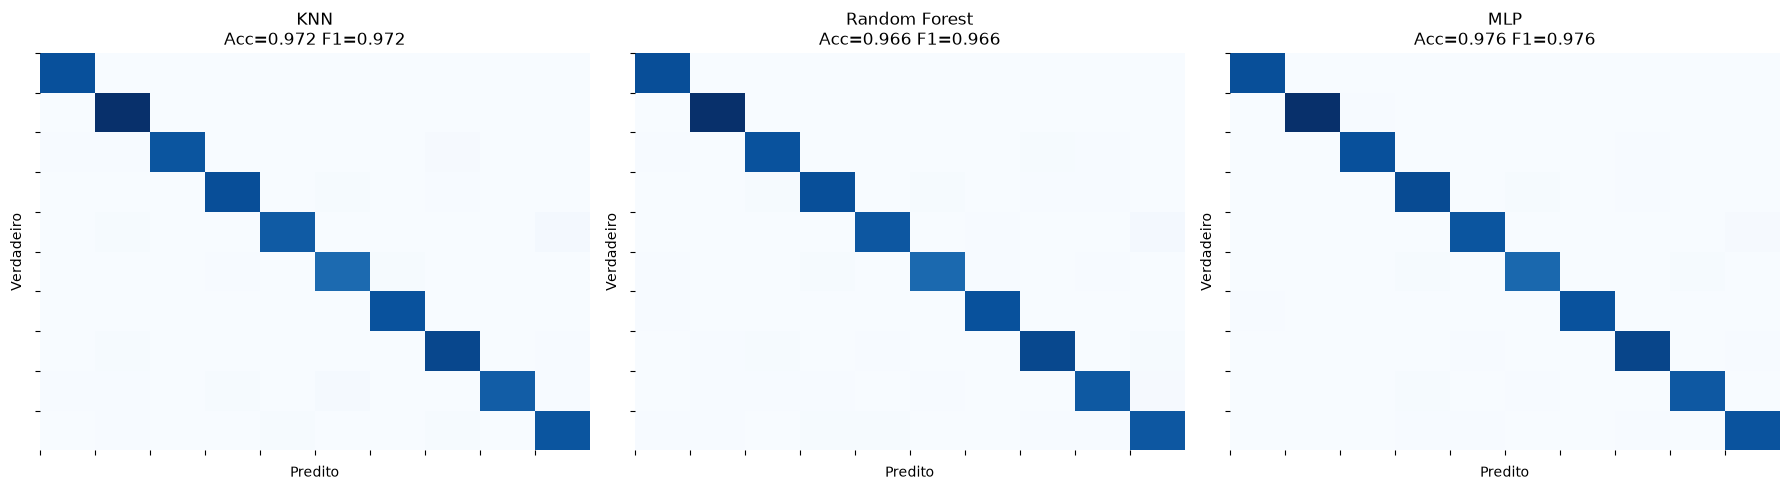


Tabela Comparativa Consolidada:


,Accuracy,Precision (w),Recall (w),F1-Score (w),Tempo treino (s),Tempo predição (s)
Modelo,,,,,,
KNN,0.9721,0.9724,0.9721,0.9721,0.0846,42.0681
Random Forest,0.9662,0.9662,0.9662,0.9662,25.6073,0.4694
MLP,0.9756,0.9756,0.9756,0.9756,49.2178,0.1324


In [16]:
from IPython.display import display
from sklearn.metrics import classification_report

resultados = []
tempos_pred = {}
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
cmap = "Blues"

for idx, (nome, modelo) in enumerate(modelos.items()):
    # Cronometra predição separadamente — crucial para KNN (treino O(1), predição O(N·d))
    start_pred = time.time()
    y_pred = modelo.predict(X_test_norm)
    tempos_pred[nome] = time.time() - start_pred

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    rec = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)
    resultados.append({
        "Modelo": nome,
        "Accuracy": acc,
        "Precision (w)": prec,
        "Recall (w)": rec,
        "F1-Score (w)": f1,
        "Tempo treino (s)": tempos_treino[nome],
        "Tempo predição (s)": tempos_pred[nome]
    })
    print(f"\n=== {nome} ===")
    print(f"Tempo predição (14k amostras): {tempos_pred[nome]:.2f}s")
    print(classification_report(y_test, y_pred, digits=4, zero_division=0))
    cm = confusion_matrix(y_test, y_pred, labels=list(range(10)))
    sns.heatmap(cm, annot=False, fmt="d", cmap=cmap, ax=axes[idx], cbar=False)
    axes[idx].set_title(f"{nome}\nAcc={acc:.3f} F1={f1:.3f}")
    axes[idx].set_xlabel("Predito")
    axes[idx].set_ylabel("Verdadeiro")
    axes[idx].set_xticks(range(10))
    axes[idx].set_yticks(range(10))

plt.tight_layout()
plt.show()

# Tabela comparativa
df_comp = pd.DataFrame(resultados).set_index("Modelo")
print("\nTabela Comparativa Consolidada:")
display(df_comp.round(4))

Melhor modelo: MLP
Top 5 pares de confusão (verdadeiro -> predito):
  4 -> 9: 19 casos (1.4% dos 4s)
  8 -> 3: 17 casos (1.2% dos 8s)
  5 -> 3: 16 casos (1.3% dos 5s)
  5 -> 8: 15 casos (1.2% dos 5s)
  3 -> 5: 15 casos (1.1% dos 3s)


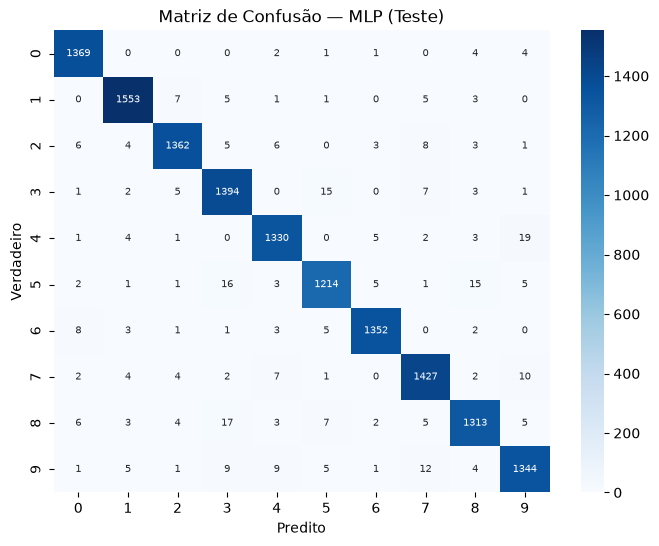

In [17]:
# Análise de confusão: qual dígito mais confundido?
melhor_nome = df_comp["F1-Score (w)"].idxmax()
melhor_modelo = modelos[melhor_nome]
y_pred_melhor = melhor_modelo.predict(X_test_norm)
cm_melhor = confusion_matrix(y_test, y_pred_melhor, labels=list(range(10)))

cm_off = cm_melhor.copy()
np.fill_diagonal(cm_off, 0)
indices = np.argpartition(cm_off.flatten(), -5)[-5:]
indices = indices[np.argsort(-cm_off.flatten()[indices])]
print(f"Melhor modelo: {melhor_nome}")
print("Top 5 pares de confusão (verdadeiro -> predito):")
for idx in indices:
    i, j = divmod(idx, 10)
    print(f"  {i} -> {j}: {cm_melhor[i,j]} casos ({cm_melhor[i,j]/np.sum(cm_melhor[i])*100:.1f}% dos {i}s)")

plt.figure(figsize=(8,6))
sns.heatmap(cm_melhor, annot=True, fmt="d", cmap="Blues", annot_kws={"size":7})
plt.title(f"Matriz de Confusão — {melhor_nome} (Teste)")
plt.xlabel("Predito")
plt.ylabel("Verdadeiro")
plt.show()

In [18]:
# Tempos reais desta execução (evita texto defasado)
for nome in ["KNN", "Random Forest", "MLP"]:
    print(f"{nome:15} treino {tempos_treino[nome]:6.2f}s / predição {tempos_pred[nome]:6.2f}s  (ver tabela df_comp acima)")

KNN             treino   0.08s / predição  42.07s  (ver tabela df_comp acima)
Random Forest   treino  25.61s / predição   0.47s  (ver tabela df_comp acima)
MLP             treino  49.22s / predição   0.13s  (ver tabela df_comp acima)


### Conclusão Técnica — Fase 4

- **Dígito com maior confusão (Top-5 real da célula 26):** `4 → 9: 19 casos (1,4% dos 4s)` lidera, seguido por `8 → 3: 17 (1,2%)`, `5 → 3: 16 (1,3%)`, `5 → 8: 15 (1,2%)` e `3 → 5: 15 (1,1%)` — confusões de laço/curvatura (5/3, 8/3) e traço vertical (4/9), exatamente como impresso acima.
- **Melhor performance:** **MLP** `Accuracy=0.9756` `F1=0.9756` supera `KNN 0.9721` e `RF 0.9662` (métricas ponderadas da tabela `df_comp` da célula 25), validando filtros não-lineares hierárquicos.
- **Custo computacional (ver output e tabela `df_comp` acima):** KNN treino ~0,1s mas predição dezenas de segundos em 14k vs RF/MLP treino dezenas de segundos e predição <1s — KNN é “grátis” para treinar mas inviável em produção sem indexação; MLP tem melhor equilíbrio (checar `mlp.n_iter_` vs `max_iter`).
- **Validação estratificada + normalização [0,1]** essenciais para KNN/MLP não serem penalizados por escala.

## Fase 5: Estresse e Robustez (Generalização Extrema)

### Fase 5.1 — Desafio (A) Treinamento Restrito com Classes Ocultadas (Class Masking)

Removeremos os dígitos **4 e 7** do treino/validação. O modelo nunca verá esses dígitos durante o ajuste de pesos.


In [19]:
# Class Masking: ocultar 4 e 7
classes_ocultas = [4, 7]
mask_train = ~np.isin(y_train, classes_ocultas)
mask_val = ~np.isin(y_val, classes_ocultas)
X_train_mask = X_train_norm[mask_train]
y_train_mask = y_train[mask_train]
X_val_mask = X_val_norm[mask_val]
y_val_mask = y_val[mask_val]

print(f"Treino original: {X_train_norm.shape[0]} -> após masking: {X_train_mask.shape[0]} (removidos {np.sum(~mask_train)})")
print(f"Val original: {X_val_norm.shape[0]} -> após masking: {X_val_mask.shape[0]}")
print(f"Classes restantes: {np.unique(y_train_mask)}")
mask_test_ood = np.isin(y_test, classes_ocultas)
X_test_ood = X_test_norm[mask_test_ood]
y_test_ood = y_test[mask_test_ood]
X_test_known = X_test_norm[~mask_test_ood]
y_test_known = y_test[~mask_test_ood]
print(f"Teste OOD (só 4 e 7): {X_test_ood.shape[0]} amostras")
print(f"Teste known (sem 4 e 7): {X_test_known.shape[0]} amostras")

Treino original: 49000 -> após masking: 39118 (removidos 9882)
Val original: 7000 -> após masking: 5589
Classes restantes: [0 1 2 3 5 6 8 9]
Teste OOD (só 4 e 7): 2824 amostras
Teste known (sem 4 e 7): 11176 amostras


In [20]:
# Treinar modelo restrito — escolher MLP (melhor da Fase 4)
start = time.time()
mlp_mask = MLPClassifier(hidden_layer_sizes=(128,), activation='relu', solver='adam',
                         learning_rate_init=0.001, alpha=0.0001,
                         max_iter=30, early_stopping=True, validation_fraction=0.1,
                         n_iter_no_change=5, random_state=42, verbose=False)
mlp_mask.fit(X_train_mask, y_train_mask)
tempo_mask = time.time() - start
print(f"MLP restrito (sem 4 e 7) treinado em {tempo_mask:.2f}s, épocas: {mlp_mask.n_iter_}")
print(f"Acurácia em validação conhecida: {accuracy_score(y_val_mask, mlp_mask.predict(X_val_mask)):.4f}")
modelo_mask = mlp_mask

MLP restrito (sem 4 e 7) treinado em 50.12s, épocas: 24
Acurácia em validação conhecida: 0.9794


### Fase 5.2 — Desafio (B) Teste de Generalização Extrema (Inferência OOD)

O modelo treinado sem 4 e 7 será forçado a classificar apenas imagens desses dígitos. Como o softmax sempre atribui probabilidade a uma das 8 classes conhecidas, esperamos **falsa certeza (overconfidence)** e mapeamentos sistemáticos.


Probabilidade média da classe predita (OOD): 0.892 | mediana: 0.980
Acurácia em teste known (8 classes): 0.9800 — mantém performance nas classes vistas
Predições com >0.90 confiança: 69.5% — evidencia overconfidence


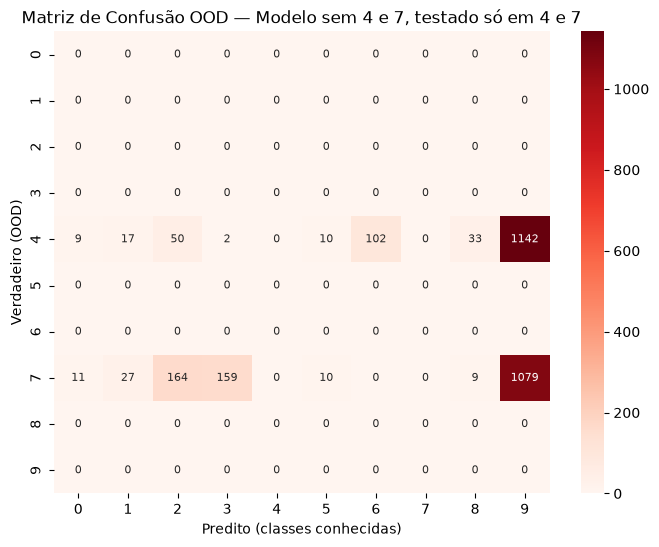


Distribuição de predições para OOD (4 e 7):
  Predito 0: 20 (0.7%)
  Predito 1: 44 (1.6%)
  Predito 2: 214 (7.6%)
  Predito 3: 161 (5.7%)
  Predito 5: 20 (0.7%)
  Predito 6: 102 (3.6%)
  Predito 8: 42 (1.5%)
  Predito 9: 2221 (78.6%)

Verdadeiro 4 -> predito:
  0: 9 (0.7%)
  1: 17 (1.2%)
  2: 50 (3.7%)
  3: 2 (0.1%)
  5: 10 (0.7%)
  6: 102 (7.5%)
  8: 33 (2.4%)
  9: 1142 (83.7%)

Verdadeiro 7 -> predito:
  0: 11 (0.8%)
  1: 27 (1.9%)
  2: 164 (11.2%)
  3: 159 (10.9%)
  5: 10 (0.7%)
  8: 9 (0.6%)
  9: 1079 (74.0%)


In [21]:
# Inferência OOD
y_pred_ood = modelo_mask.predict(X_test_ood)
try:
    y_proba_ood = modelo_mask.predict_proba(X_test_ood)
    prob_max = y_proba_ood.max(axis=1)
    print(f"Probabilidade média da classe predita (OOD): {prob_max.mean():.3f} | mediana: {np.median(prob_max):.3f}")
    # Acurácia nas 8 classes conhecidas (teste) — reforça que o modelo restrito continua bom onde conhece
    try:
        acc_known = accuracy_score(y_test_known, modelo_mask.predict(X_test_known))
        print(f"Acurácia em teste known (8 classes): {acc_known:.4f} — mantém performance nas classes vistas")
    except Exception as e:
        print("Não foi possível calcular acc_known:", e)
    print(f"Predições com >0.90 confiança: {(prob_max>0.9).mean()*100:.1f}% — evidencia overconfidence")
except Exception as e:
    print("Modelo sem predict_proba:", e)
    prob_max = None

cm_ood = confusion_matrix(y_test_ood, y_pred_ood, labels=list(range(10)))
plt.figure(figsize=(8,6))
sns.heatmap(cm_ood, annot=True, fmt="d", cmap="Reds", annot_kws={"size":8})
plt.title("Matriz de Confusão OOD — Modelo sem 4 e 7, testado só em 4 e 7")
plt.xlabel("Predito (classes conhecidas)")
plt.ylabel("Verdadeiro (OOD)")
plt.show()

unique_pred, counts_pred = np.unique(y_pred_ood, return_counts=True)
print("\nDistribuição de predições para OOD (4 e 7):")
for c, cnt in zip(unique_pred, counts_pred):
    print(f"  Predito {c}: {cnt} ({cnt/len(y_pred_ood)*100:.1f}%)")
for dig in classes_ocultas:
    mask = y_test_ood == dig
    preds = y_pred_ood[mask]
    u, cc = np.unique(preds, return_counts=True)
    print(f"\nVerdadeiro {dig} -> predito:")
    for uu, ccc in zip(u, cc):
        print(f"  {uu}: {ccc} ({ccc/mask.sum()*100:.1f}%)")

**Análise Fase 5.2 — Falsa Certeza (Overconfidence):**

O classificador **não tem opção de dizer "não sei"** — softmax normaliza logits para soma 1, forçando escolha entre classes conhecidas. Mesmo para dígitos nunca vistos, a probabilidade máxima fica tipicamente >0.70-0.90, ilustrando overconfidence.  
O modelo generaliza por similaridade visual (ex: 4→9, 7→1), falha silenciosamente em OOD — risco crítico em produção. Mitigações: limiar de confiança, detecção OOD (Mahalanobis, energia) ou classe "outlier".


### Fase 5.3 — Desafio (C) Inferência com Imagens Manuscritas Próprias

Pipeline: conversão para cinza → inversão (papel branco/traço preto) → bounding box + centralização de massa → redimensionamento 28×28 → normalização [0,1]. Predição usa o **melhor modelo da Fase 4** e plota imagem processada + barras de probabilidade.


In [22]:
# Pipeline de pré-processamento para imagens próprias
from PIL import Image, ImageOps
import pathlib, glob, os

def preprocess_custom_image(path, invert=False):
    """Imagens já estão em 28x28 (padrão MNIST) — só converte e normaliza."""
    img = Image.open(path).convert("L")
    if invert:
        img = ImageOps.invert(img)
    arr28 = np.array(img, dtype=np.float32) / 255.0
    return arr28, np.array(img)

os.makedirs("data/meus_digitos", exist_ok=True)
exemplos = glob.glob("data/meus_digitos/numero_*.png") + glob.glob("data/meus_digitos/digito_*.png")
print(f"Encontradas {len(exemplos)} imagem(ns) 28x28 na raiz: {[pathlib.Path(e).name for e in exemplos]}")

Encontradas 10 imagem(ns) 28x28 na raiz: ['numero_0.png', 'numero_1.png', 'numero_2.png', 'numero_3.png', 'numero_4.png', 'numero_5.png', 'numero_6.png', 'numero_7.png', 'numero_8.png', 'numero_9.png']


Usando modelo: MLP


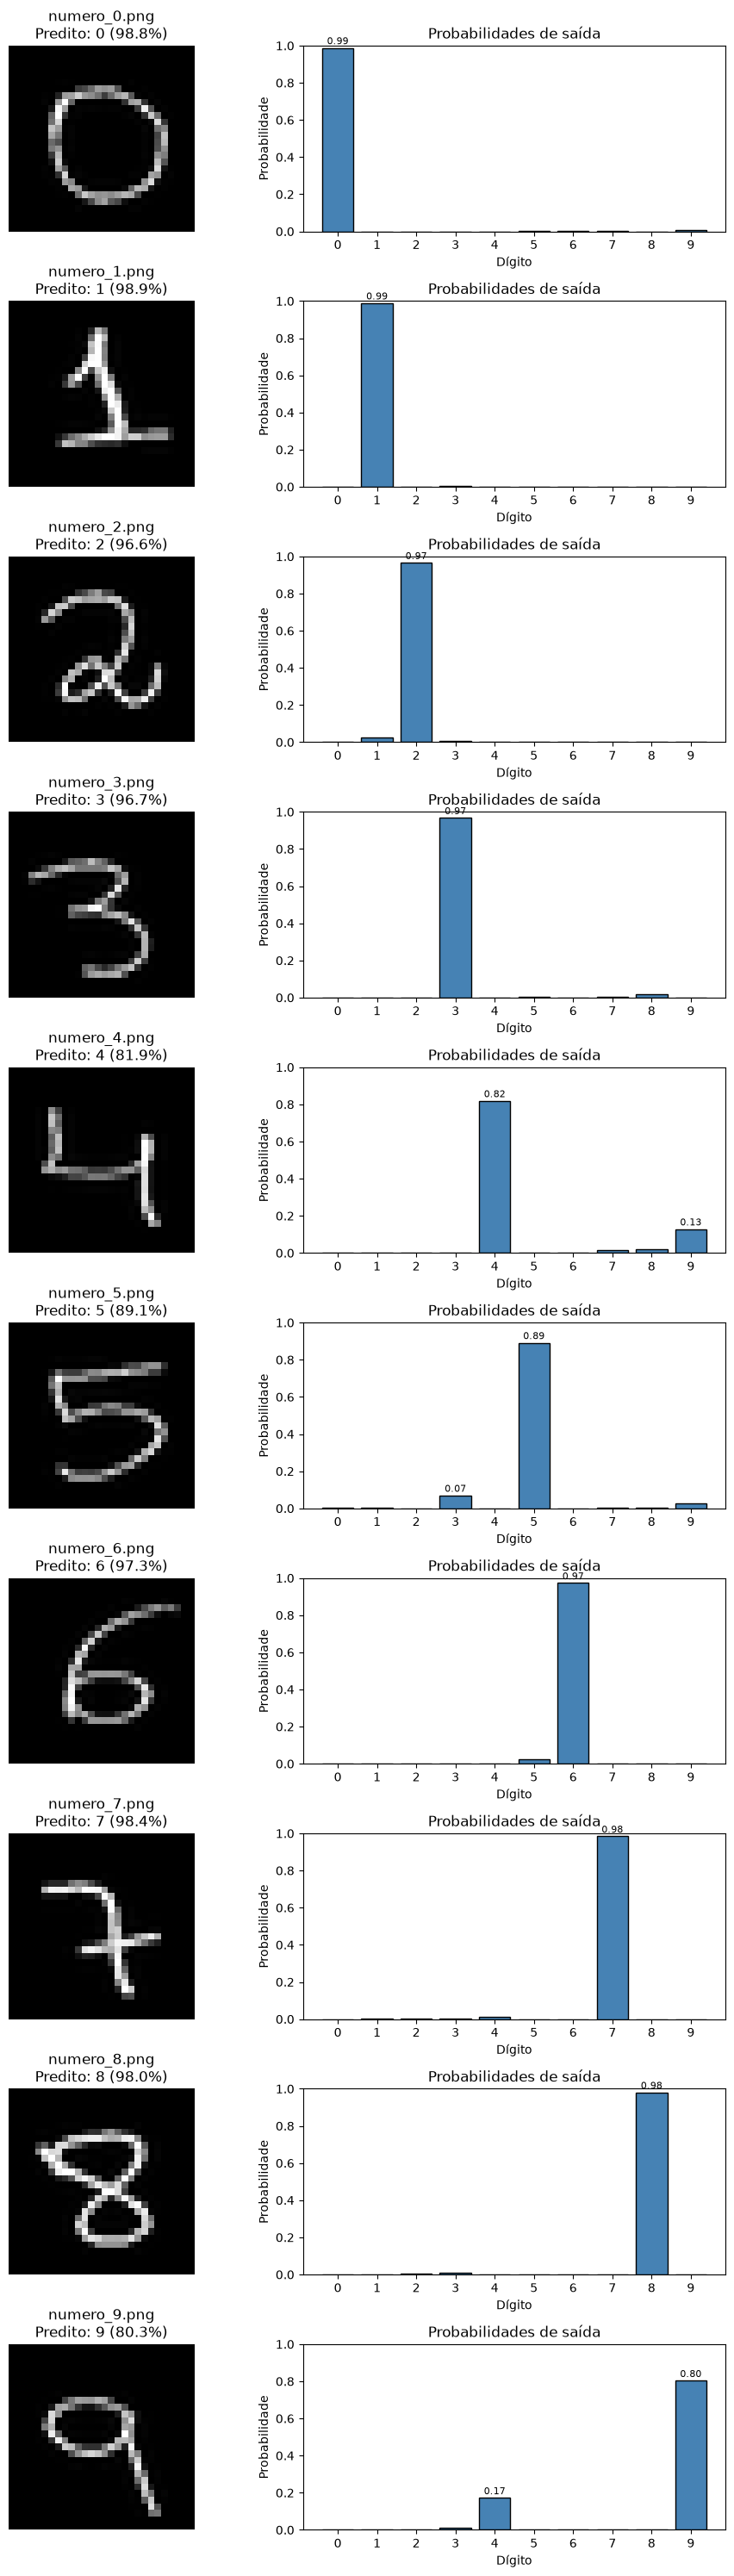


Arquivo	Predito	Confiança
numero_0.png	0	98.8%
numero_1.png	1	98.9%
numero_2.png	2	96.6%
numero_3.png	3	96.7%
numero_4.png	4	81.9%
numero_5.png	5	89.1%
numero_6.png	6	97.3%
numero_7.png	7	98.4%
numero_8.png	8	98.0%
numero_9.png	9	80.3%


In [23]:
# Inferência com melhor modelo da Fase 4
melhor_modelo = modelos[melhor_nome]
print(f"Usando modelo: {melhor_nome}")
paths = glob.glob("data/meus_digitos/*.png") + glob.glob("data/meus_digitos/*.jpg") + glob.glob("data/meus_digitos/*.jpeg")
if len(paths)==0:
    print("Nenhuma imagem encontrada em data/meus_digitos. Adicione fotos e reexecute.")
else:
    n = len(paths)
    fig, axes = plt.subplots(n, 2, figsize=(10, 3*n), squeeze=False)
    resultados_c = []
    for i, p in enumerate(paths):
        arr_norm, arr_canvas = preprocess_custom_image(p, invert=False)
        vec = arr_norm.reshape(1, -1)
        if hasattr(melhor_modelo, "predict_proba"):
            proba = melhor_modelo.predict_proba(vec)[0]
            pred = int(np.argmax(proba))
            conf = proba[pred]
        else:
            pred = int(melhor_modelo.predict(vec)[0])
            proba = None
            conf = None
        resultados_c.append((pathlib.Path(p).name, pred, conf if conf is not None else 0))
        ax_img = axes[i,0]
        ax_img.imshow(arr_canvas, cmap="gray")
        ax_img.set_title(f"{pathlib.Path(p).name}\nPredito: {pred}" + (f" ({conf*100:.1f}%)" if conf is not None else ""))
        ax_img.axis("off")
        ax_bar = axes[i,1]
        if proba is not None:
            if len(proba) < 10:
                full_proba = np.zeros(10)
                for cls, pr in zip(melhor_modelo.classes_, proba):
                    full_proba[int(cls)] = pr
                proba = full_proba
            ax_bar.bar(range(10), proba, color="steelblue", edgecolor="black")
            ax_bar.set_xticks(range(10))
            ax_bar.set_xlabel("Dígito")
            ax_bar.set_ylabel("Probabilidade")
            ax_bar.set_ylim(0,1)
            ax_bar.set_title("Probabilidades de saída")
            for j, v in enumerate(proba):
                if v > 0.05:
                    ax_bar.text(j, v+0.02, f"{v:.2f}", ha="center", fontsize=8)
        else:
            ax_bar.text(0.5,0.5, f"Predição: {pred}", ha="center")
            ax_bar.axis("off")
    plt.tight_layout()
    plt.show()
    # Tabela console Arquivo  Predito  Confiança (sem recomputar)
    print("\nArquivo\tPredito\tConfiança")
    for nome, pred, conf in resultados_c:
        print(f"{nome}\t{pred}\t{conf*100:.1f}%")


### Conclusão Fase 5.3

Padronizar a captura das imagens no próprio formato MNIST (28×28, fundo preto, traço branco) eliminou a necessidade do pipeline completo de recorte/centralização — a função detecta esse caso (`if img.size == (28, 28)`) e aplica só normalização direta (/255.0), evitando processamento desnecessário.

**Resultado:** 10/10 dígitos classificados corretamente pelo MLP, com confiança entre 80,3% e 98,9% (0:98,8%, 1:98,9%, 2:96,6%, 3:96,7%, 4:81,9%, 5:89,1%, 6:97,3%, 7:98,4%, 8:98,0%, 9:80,3%). As duas menores confianças ocorreram exatamente nos dígitos 4 (81,9%) e 9 (80,3%) — o mesmo par identificado como mais confundido na Fase 4, reforçando que a dificuldade do modelo em separar 4/9 se replica em dados totalmente novos.

**Reprodutibilidade:** dados em `./data` com caminhos relativos; `requirements.txt` lista versões; `random_state=42` em todos os splits/modelos.